# Start Up

Upload the modules

In [5]:
%pip install pandas
%pip install numpy
%pip install -U matplotlib
%pip install scipy
%pip install math
%pip install openpyxl
%pip install scikit-learn
%pip install SALib
%pip install pyDOE
%pip install h5py




import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit, minimize
import math as math
import os 
import warnings
from sklearn.metrics import r2_score 
import copy
import subprocess
from PIL import Image
import scipy.stats as stats
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from SALib.sample import saltelli
from SALib.analyze import sobol
import json
import datetime
from scipy.stats import t
from pyDOE import lhs
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit, minimize
import math as math
import os 
import warnings
import copy
import subprocess
from PIL import Image
from scipy.optimize import approx_fprime
import importlib
import textwrap
import sys





[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement math (from versions: none)
ERROR: No matching distribution found for math

[notice] A new release of pip available: 22.2.2 -> 25.0.1
[notice] To update, run: python3.10 -m pip i

In [159]:
import functions_fitting
from functions_fitting import *
importlib.reload(functions_fitting)

import data_reading_inputs
from data_reading_inputs import *
importlib.reload(data_reading_inputs)

<module 'data_reading_inputs' from '/Users/yagmurbalabanli/GitLab/LAOS_fit_lauren/vdSman_Constitutive_Model_Fitting/data_reading_inputs.py'>

# Read Data

Some explaianition of the datasets:

**Freq Sweep** <br /> 
data_exp_frswp = [ [ [freq],[G'],[G''] ] , [ [[freq],[G'],[G''] ] ]<br /> 
                           rep1          ,           rep2<br /> 
data_exp_frswp_avg = [ [ [freq],[G'],[G''] ] ] only the average, freq values coming from the rep1<br /> 
std_frq_swp = [ [std for G1],[std for G2] ]

**Amplitude Sweep** <br /> 
data_exp_frswp = [ [ [ampl],[G'],[G''] ] , [ [ampl],[G'],[G''] ] ]<br /> 
                           rep1          ,           rep2<br /> 
data_exp_frswp_avg = [ [ [ampl],[G'],[G''] ] ] only the average, strain values coming from the rep1<br /> 
std_str_swp= [ [std for G1],[std for G2] ]

**LAOS** <br /> 
data_exp = [ [ [time],[stress],[strain],[shrate] ] , [ [time],[stress],[strain],[shrate] ], ...,   ] <br /> 
first 2Hz for each strain(7), replicates contunie in series, then 4Hz each strain(7) and replicates<br /> 
data_exp_avg =  the same above but replicates averaged, hence only one set of strain amplitudes(7) at 2Hz then 4Hz (14 elements total with 4 subseries each) <br /> 
std_all = array containgin std dev in strain for each  amplitude


**Stress Growth** <br /> 
15 shear rates, followed by 15 replictaes.<br /> 
Each element of "data_exp_stgrw" contains 3 sub elements: time, strain, shear rate, each 99 elements<br /> 
"data_exp_stgrw_avg" contains average of replictaes, the same format with 15 averaged values. The strain and time were extractedfrom the first replicate. <br /> 
std_grw = has 15 elements each  containing 99 elements for each of the stress value collected at a certain time/strain for wach given shear rate

## Freq Sweep

### Viscoelastic moduli

In [141]:
#   Inputs

def remove_nan(arr):
    return [x for x in arr if not (isinstance(x, float) and math.isnan(x))]

n_header= 2 #header rows just from the begining to the first data
n_rows=513*9 #number of data points in the measurement
rows_btw_data = 7 #number20 of rows between two measurements
header_list=['Point No.',	'Shear Strain',	'Shear Strain wave',	'Shear Stress',	'Shear Stress wave',\
            'Storage Modulus',	'Loss Modulus',	'Loss Factor',	'Deflection Angle',\
            'Torque',	'Status',	'Shear Rate (for sinusoidal strain)',	'Period Time',]
what_to_collect_single_val = []
sheet_name = 'PF Frequency Sweep'
sample_list = ['01-frswp-P60-0.60-1','01-frswp-P60-0.60-2']    
what_to_collect_time_dep = ['Storage Modulus','Loss Modulus']

#   Function
data_exp_frswp_raw = read_data1(n_header, n_rows, header_list, what_to_collect_time_dep,\
               path_read, sheet_name, sample_list, rows_btw_data)

freq = np.logspace(-1,1,9)
for i in range(0,len(sample_list)): #replicates
    for l in range(0,len(what_to_collect_time_dep)): #number of cols
        data_exp_frswp_raw[i][l] = remove_nan(data_exp_frswp_raw[i][l])
        
data_exp_frswp = []
for i in range(0,len(sample_list)): #replicates
    data_exp_frswp.append([list(freq),data_exp_frswp_raw[i][0],data_exp_frswp_raw[i][1]])
    
print(data_exp_frswp)



4626
9250
[[[0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0], [12201.0, 13026.0, 13770.0, 14511.0, 15300.0, 16165.0, 17144.0, 18276.0, 19643.0], [2356.2, 2338.5, 2446.0, 2632.1, 2892.6, 3236.2, 3676.1, 4231.9, 4919.8]], [[0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0], [18341.0, 19598.0, 20709.0, 21798.0, 22953.0, 24197.0, 25593.0, 27173.0, 29015.0], [3797.3, 3665.1, 3769.8, 3990.4, 4318.4, 4754.9, 5316.8, 6024.5, 6900.5]]]


Average the replicates

[[15271.0, 16312.0, 17239.5, 18154.5, 19126.5, 20181.0, 21368.5, 22724.5, 24329.0], [3076.75, 3001.8, 3107.9, 3311.25, 3605.5, 3995.5499999999997, 4496.45, 5128.2, 5910.15]]
[[3070.0, 3286.0, 3469.5, 3643.5, 3826.5, 4016.0, 4224.5, 4448.5, 4686.0], [720.5500000000002, 663.3, 661.9000000000001, 679.1500000000001, 712.8999999999999, 759.3499999999999, 820.3500000000001, 896.3000000000002, 990.3499999999999]]
[[[0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0], [15271.0, 16312.0, 17239.5, 18154.5, 19126.5, 20181.0, 21368.5, 22724.5, 24329.0], [3076.75, 3001.8, 3107.9, 3311.25, 3605.5, 3995.5499999999997, 4496.45, 5128.2, 5910.15]]]


<ErrorbarContainer object of 3 artists>

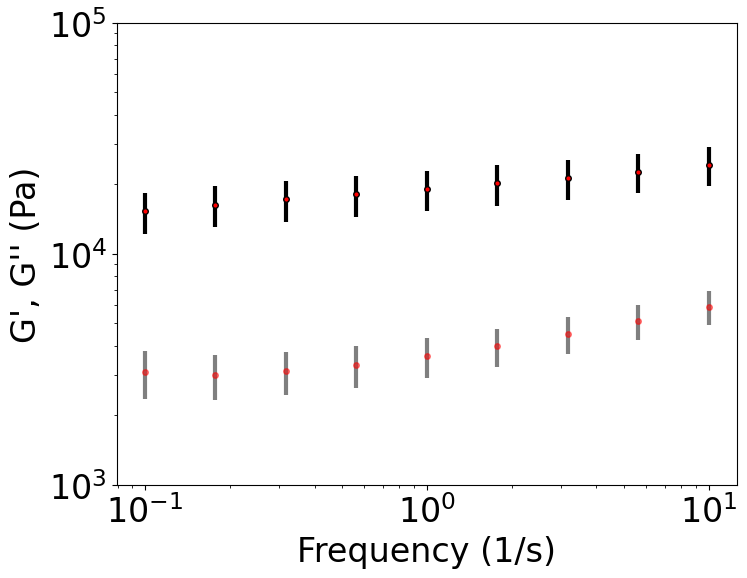

In [142]:
G1rep1 = data_exp_frswp[0][1]
G1rep2 = data_exp_frswp[1][1]

G2rep1 = data_exp_frswp[0][2]
G2rep2 = data_exp_frswp[1][2]

avg = [[],[]]
std_freq_swp = [[],[]]
for i in range(0,len(G1rep1)):
    avg[0].append(np.average([G1rep1[i], G1rep2[i]]))
    avg[1].append(np.average([G2rep1[i], G2rep2[i]]))
    std_freq_swp[0].append(np.std([G1rep1[i], G1rep2[i]]))
    std_freq_swp[1].append(np.std([G2rep1[i], G2rep2[i]]))

print(avg)
print(std_freq_swp)
data_exp_frswp_avg = [[]]
for i in range(0,3):
    if i == 0: data_exp_frswp_avg[0].append(data_exp_frswp[0][0])
    if i == 1: data_exp_frswp_avg[0].append(avg[0])
    if i == 2: data_exp_frswp_avg[0].append(avg[1])
print(data_exp_frswp_avg)

# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_xscale('log')
axs.set_yscale('log')


axs.set_xlabel('Frequency (1/s)')
axs.set_ylabel("G', G'' (Pa)")

axs.set_ylim(1e3, 1e5)

axs.errorbar(data_exp_frswp_avg[0][0], data_exp_frswp_avg[0][1], yerr=std_freq_swp[0], marker='o', color='red',\
              label='Data 1', markersize=4, linewidth =0, ecolor = 'black', elinewidth=3, markeredgecolor='black')
axs.errorbar(data_exp_frswp_avg[0][0], data_exp_frswp_avg[0][2], yerr=std_freq_swp[1], marker='o', color=color_palette[0],\
              label='Data 1', markersize=4, linewidth =0, ecolor = 'black', elinewidth=3, alpha =0.5)




### Waveform Data

In [143]:
#Inputs
n_header= 2 #header rows just from the begining to the first data
n_rows=513*9 #number of data points in the measurement
rows_btw_data = 7 #number20 of rows between two measurements
header_list=['Point No.',	'Shear Strain',	'Shear Strain wave',	'Shear Stress',	'Shear Stress wave',\
            'Storage Modulus',	'Loss Modulus',	'Loss Factor',	'Deflection Angle',\
            'Torque',	'Status',	'Shear Rate (for sinusoidal strain)',	'Period Time',]
what_to_collect_single_val = []
sheet_name = 'PF Frequency Sweep'
sample_list = ['01-frswp-P60-0.60-1','01-frswp-P60-0.60-2']    
what_to_collect_time_dep = ['Period Time','Shear Stress wave','Shear Strain wave','Shear Rate (for sinusoidal strain)']

#   Function
data_exp_frswp_waveform = read_data1(n_header, n_rows, header_list, what_to_collect_time_dep,\
               path_read, sheet_name, sample_list, rows_btw_data)

print(data_exp_frswp_waveform)

4626
9250
[[[0.0, 0.019531, 0.039063, 0.058594, 0.078125, 0.097656, 0.11719, 0.13672, 0.15625, 0.17578, 0.19531, 0.21484, 0.23438, 0.25391, 0.27344, 0.29297, 0.3125, 0.33203, 0.35156, 0.37109, 0.39063, 0.41016, 0.42969, 0.44922, 0.46875, 0.48828, 0.50781, 0.52734, 0.54688, 0.56641, 0.58594, 0.60547, 0.625, 0.64453, 0.66406, 0.68359, 0.70313, 0.72266, 0.74219, 0.76172, 0.78125, 0.80078, 0.82031, 0.83984, 0.85938, 0.87891, 0.89844, 0.91797, 0.9375, 0.95703, 0.97656, 0.99609, 1.0156, 1.0352, 1.0547, 1.0742, 1.0938, 1.1133, 1.1328, 1.1523, 1.1719, 1.1914, 1.2109, 1.2305, 1.25, 1.2695, 1.2891, 1.3086, 1.3281, 1.3477, 1.3672, 1.3867, 1.4063, 1.4258, 1.4453, 1.4648, 1.4844, 1.5039, 1.5234, 1.543, 1.5625, 1.582, 1.6016, 1.6211, 1.6406, 1.6602, 1.6797, 1.6992, 1.7188, 1.7383, 1.7578, 1.7773, 1.7969, 1.8164, 1.8359, 1.8555, 1.875, 1.8945, 1.9141, 1.9336, 1.9531, 1.9727, 1.9922, 2.0117, 2.0313, 2.0508, 2.0703, 2.0898, 2.1094, 2.1289, 2.1484, 2.168, 2.1875, 2.207, 2.2266, 2.2461, 2.2656, 2.2852, 2

Average the replicates

4617


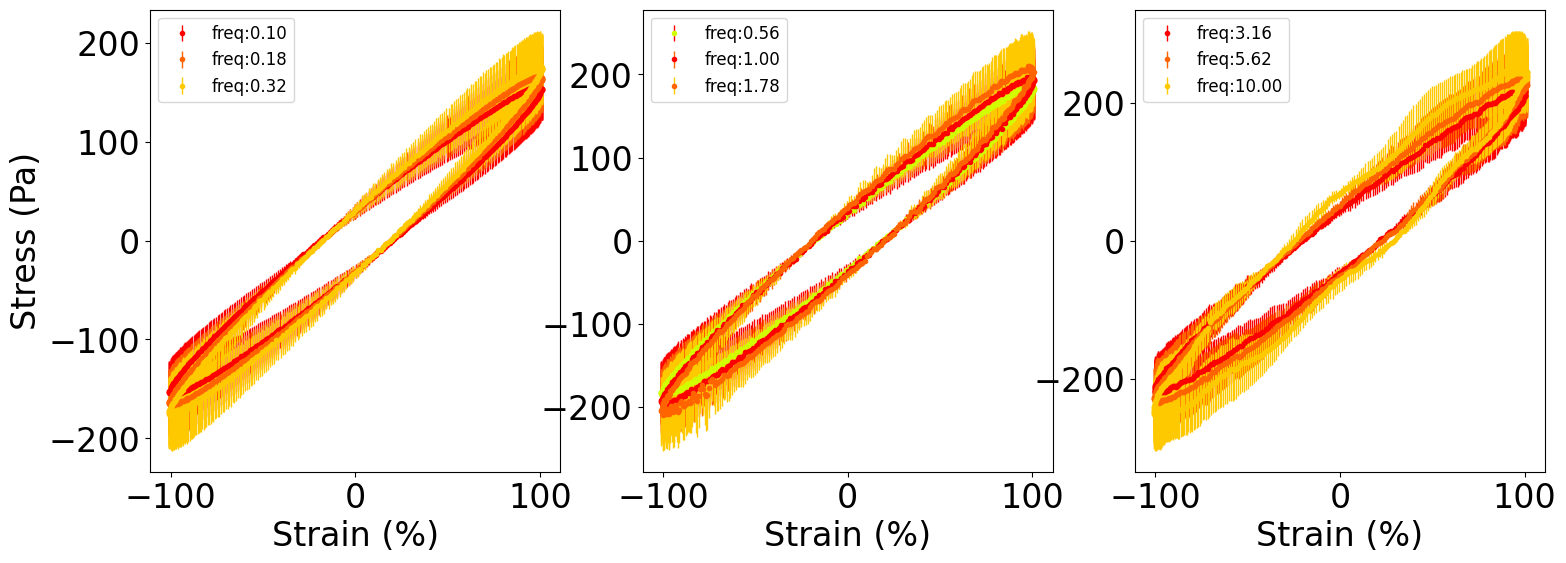

In [144]:
rep1 = data_exp_frswp_waveform[0][1]
rep2 = data_exp_frswp_waveform[1][1]

avg = []
std_freqwaveform = []
for i in range(0,len(rep1)):
    avg.append(np.average([rep1[i], rep2[i]]))
    std_freqwaveform.append(np.std([rep1[i], rep2[i]]))


elem1 = data_exp_frswp_waveform[0][0]
elem2 = avg
elem3 = data_exp_frswp_waveform[0][2]
elem4 = data_exp_frswp_waveform[0][3]

data_exp_frswp_waveform_avg = [[[elem1, elem2, elem3, elem4]]]

fig, axs = plt.subplots(1,3,figsize=(18, 6))

axs[0].set_xlabel('Strain (%)')
axs[1].set_xlabel('Strain (%)')
axs[2].set_xlabel('Strain (%)')
axs[0].set_ylabel("Stress (Pa)")

print(len(data_exp_frswp_waveform_avg[0][0][2]))

for i in range(0,len(freqvals_frfit)):
    x= np.multiply(data_exp_frswp_waveform_avg[0][0][2][i*ndata_cycle:(i+1)*ndata_cycle],100)
    if i <= 2:
        axs[0].errorbar(x, data_exp_frswp_waveform_avg[0][0][1][i*ndata_cycle:(i+1)*ndata_cycle], yerr=std_freqwaveform[i*ndata_cycle:(i+1)*ndata_cycle],\
             marker='o', linewidth=0, markersize=3, color=color_palette[i%4], ecolor=color_palette[i], elinewidth = 1,
             label=f'freq:{freqvals_frfit[i]:.2f}')
    elif i < 6:
        axs[1].errorbar(x, data_exp_frswp_waveform_avg[0][0][1][i*ndata_cycle:(i+1)*ndata_cycle], yerr=std_freqwaveform[i*ndata_cycle:(i+1)*ndata_cycle],\
             marker='o', linewidth=0, markersize=3, color=color_palette[i%4], ecolor=color_palette[i%3], elinewidth = 1,
             label=f'freq:{freqvals_frfit[i]:.2f}')
    else:
        axs[2].errorbar(x, data_exp_frswp_waveform_avg[0][0][1][i*ndata_cycle:(i+1)*ndata_cycle], yerr=std_freqwaveform[i*ndata_cycle:(i+1)*ndata_cycle],\
             marker='o', linewidth=0, markersize=3, color=color_palette[i%3], ecolor=color_palette[i%3], elinewidth = 1,
             label=f'freq:{freqvals_frfit[i]:.2f}')
        
axs[0].legend(fontsize=12)
axs[1].legend(fontsize=12)
axs[2].legend(fontsize=12)


## Amplitude Sweep

In [147]:
def remove_nan(arr):
    return [x for x in arr if not (isinstance(x, float) and math.isnan(x))]

n_header= 2 #header rows just from the begining to the first data
n_rows=513*21 #number of data points in the measurement
rows_btw_data = 7 #number20 of rows between two measurements
header_list=['Point No.',	'Shear Strain',	'Shear Strain wave',	'Shear Stress',	'Shear Stress wave',\
            'Storage Modulus',	'Loss Modulus',	'Loss Factor',	'Deflection Angle',\
            'Torque',	'Status',	'Shear Rate (for sinusoidal strain)',	'Period Time',]
what_to_collect_single_val = []
sheet_name = 'PF Strain Sweep'
sample_list = ['01-strswp-P60-0.60-1', 
               '02-strswp-P60-0.60-2']    
what_to_collect_time_dep = ['Shear Strain','Storage Modulus','Loss Modulus']

#   Function
data_exp_strswp = read_data1(n_header, n_rows, header_list, what_to_collect_time_dep,\
               path_read, sheet_name, sample_list, rows_btw_data)

#freq = np.logspace(-1,1,9)
for i in range(0,len(sample_list)): #replicates
    for l in range(0,len(what_to_collect_time_dep)): #number of cols
        data_exp_strswp[i][l] = remove_nan(data_exp_strswp[i][l])
        
# data_exp_frswp = []
# for i in range(0,len(sample_list)): #replicates
#     data_exp_frswp.append([list(freq),data_exp_frswp_raw[i][0],data_exp_frswp_raw[i][1]])
    
# print(data_exp_frswp)

print(data_exp_strswp)

10782
21562
[[[0.00982, 0.0174, 0.0316, 0.0567, 0.101, 0.181, 0.323, 0.576, 1.03, 1.83, 3.25, 5.79, 10.3, 18.3, 32.6, 58.0, 103.0, 183.0, 326.0, 578.0, 1030.0], [18081.0, 18495.0, 18390.0, 18312.0, 18239.0, 18106.0, 17847.0, 17371.0, 16567.0, 15457.0, 14025.0, 12266.0, 10270.0, 8196.1, 6233.5, 4524.8, 3154.3, 2058.2, 1111.9, 472.62, 194.93], [3409.8, 3310.5, 3312.3, 3301.2, 3313.3, 3335.9, 3378.6, 3437.1, 3498.3, 3568.0, 3621.9, 3627.3, 3563.9, 3418.7, 3208.3, 2968.2, 2724.7, 2452.7, 1962.0, 1238.1, 750.91]], [[0.00982, 0.0181, 0.0323, 0.0576, 0.103, 0.182, 0.325, 0.577, 1.03, 1.82, 3.24, 5.77, 10.3, 18.3, 32.5, 57.7, 103.0, 182.0, 324.0, 577.0, 1030.0], [28169.0, 28204.0, 28060.0, 28074.0, 27938.0, 27645.0, 27067.0, 26161.0, 24838.0, 22849.0, 20284.0, 17277.0, 14016.0, 10779.0, 7857.2, 5467.6, 3567.0, 1905.5, 886.3, 396.11, 163.29], [4912.0, 4858.9, 4817.4, 4829.8, 4829.2, 4845.5, 4886.6, 4977.3, 5130.0, 5284.7, 5403.4, 5433.1, 5301.1, 4991.3, 4540.4, 4020.8, 3452.3, 2596.8, 1727.9, 1

Average the replicates

<ErrorbarContainer object of 3 artists>

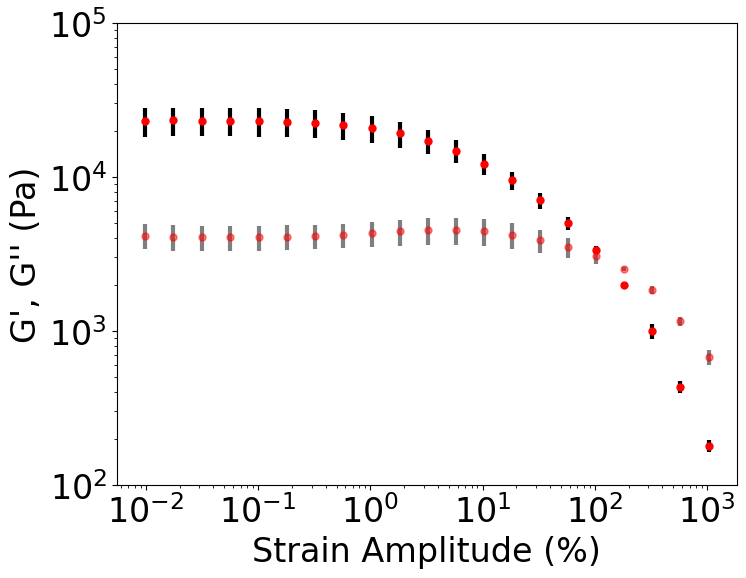

In [148]:
G1rep1 = data_exp_strswp[0][1]
G1rep2 = data_exp_strswp[1][1]

G2rep1 = data_exp_strswp[0][2]
G2rep2 = data_exp_strswp[1][2]

avg = [[],[]]
std_str_swp = [[],[]]
for i in range(0,len(G1rep1)):
    avg[0].append(np.average([G1rep1[i], G1rep2[i]]))
    avg[1].append(np.average([G2rep1[i], G2rep2[i]]))
    std_str_swp[0].append(np.std([G1rep1[i], G1rep2[i]]))
    std_str_swp[1].append(np.std([G2rep1[i], G2rep2[i]]))

data_exp_strswp_avg = [[]]
for i in range(0,3):
    if i == 0: data_exp_strswp_avg[0].append(data_exp_strswp[0][0])
    if i == 1: data_exp_strswp_avg[0].append(avg[0])
    if i == 2: data_exp_strswp_avg[0].append(avg[1])

# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(figsize=(8, 6))
axs.set_xscale('log')
axs.set_yscale('log')

axs.set_xlabel('Strain Amplitude (%)')
axs.set_ylabel("G', G'' (Pa)")

axs.set_ylim(1e2, 1e5)

axs.errorbar(data_exp_strswp_avg[0][0], data_exp_strswp_avg[0][1], yerr=std_str_swp[0], marker='o', color=color_palette[0],\
              label='Data 1', markersize=5, linewidth =0, ecolor = 'black', elinewidth=3)
axs.errorbar(data_exp_strswp_avg[0][0], data_exp_strswp_avg[0][2], yerr=std_str_swp[1], marker='o', color=color_palette[0],\
              label='Data 1', markersize=5, linewidth =0, ecolor = 'black', elinewidth=3, alpha =0.5)




## LAOS

In [168]:
#   Inputs
n_header= 2 #header rows just from the begining to the first data
n_rows=513*10 #number of data points in the measurement
rows_btw_data = 0 #number of rows between two measurements
header_list=['Point No.',	'Shear Strain',	'Shear Strain wave',	'Shear Stress',	'Shear Stress wave',\
            'Storage Modulus',	'Loss Modulus',	'Loss Factor',	'Deflection Angle',\
            'Torque',	'Status',	'Shear Rate (for sinusoidal strain)',	'Period Time',]
what_to_collect_time_dep= ['Period Time', 'Shear Stress wave','Shear Strain wave','Shear Rate (for sinusoidal strain)'  ]
what_to_collect_single_val = []
sheet_name = ['PF A80 F2',
              'PF A70 F2',
              'PF A55 F2',
              'PF A25 F2',
              'PF A1 F2',
              'PF A80 F2 (2)',
              'PF A70 F2 (2)',
              'PF A55 F2 (2)',
              'PF A25 F2 (2)',
              'PF A1 F2 (2)',
              'PF A80 F6',
              'PF A70 F6',
              'PF A55 F6',
              'PF A25 F6',
              'PF A1 F12',
              'PF A80 F6 (2)',
              'PF A70 F6 (2)',
              'PF A55 F6 (3)',
              'PF A25 F6 (2)',
              'PF A1 F12 (2)',
              'PF A80 F12',
              'PF A70 F12',
              'PF A55 F12',
              'PF A25 F12',
              'PF A1 F12',
              'PF A80 F12 (2)',
              'PF A70 F12 (2)',
              'PF A55 F12 (2)',
              'PF A25 F12 (2)',
              'PF A1 F12 (2)',
              ]

sample_list = ['01-laos-P60-0.60-1.2-freq2.0',\
               '02-laos-P60-0.60-1.0-freq2.0',\
               '03-laos-P60-0.60-0.5-freq2.0',\
               '04-laos-P60-0.60-0.3-freq2.0',\
               '05-laos-P60-0.60-0.15-freq2.0',\
               '06-laos-P60-0.60-0.1-freq2.0',\
               '07-laos-P60-0.60-0.05-freq2.0',\
               '08-laos-P60-0.60-1.2-freq2.0-2',\
               '09-laos-P60-0.60-1.0-freq2.0-2',\
               '10-laos-P60-0.60-0.5-freq2.0-2',\
               '11-laos-P60-0.60-0.3-freq2.0-2',\
               '12-laos-P60-0.60-0.1-freq2.0-2',\
               '13-laos-P60-0.60-0.15-freq2.0-2',\
               '14-laos-P60-0.60-0.05-freq2.0-2',\
               '15-laos-P60-0.60-1.2-freq2.0-2',\
               '16-laos-P60-0.60-1.0-freq4.0',\
               '17-laos-P60-0.60-0.5-freq4.0',\
               '18-laos-P60-0.60-0.3-freq4.0',\
               '19-laos-P60-0.60-0.15-freq4.0',\
               '20-laos-P60-0.60-0.1-freq4.0',\
               '21-laos-P60-0.60-0.05-freq4.0',\
               '22-laos-P60-0.60-1.2-freq4.0-2',\
               '23-laos-P60-0.60-1.0-freq4.0-2',\
               '24-laos-P60-0.60-0.5-freq4.0-2',\
               '25-laos-P60-0.60-0.3-freq4.0-2',\
               '26-laos-P60-0.60-0.15-freq4.0-2',\
               '27-laos-P60-0.60-0.1-freq4.0-2',\
               '28-laos-P60-0.60-0.05-freq4.0-2',\
               '29-laos-P60-0.60-1.2-freq2.0-2',\
               '30-laos-P60-0.60-1.0-freq8.0',\
                ]    

#   Function
data_exp, data_single_exp = read_data_sheets(n_header, n_rows, header_list, what_to_collect_time_dep,what_to_collect_single_val,\
               path_read, sheet_name, sample_list, rows_btw_data, cyclesdata, ndata_percycle)


PF A80 F2
PF A70 F2
PF A55 F2
PF A25 F2
PF A1 F2
PF A80 F2 (2)
PF A70 F2 (2)
PF A55 F2 (2)
PF A25 F2 (2)
PF A1 F2 (2)
PF A80 F6
PF A70 F6
PF A55 F6
PF A25 F6
PF A1 F12
PF A80 F6 (2)
PF A70 F6 (2)
PF A55 F6 (3)
PF A25 F6 (2)
PF A1 F12 (2)
PF A80 F12
PF A70 F12
PF A55 F12
PF A25 F12
PF A1 F12
PF A80 F12 (2)
PF A70 F12 (2)
PF A55 F12 (2)
PF A25 F12 (2)
PF A1 F12 (2)


513


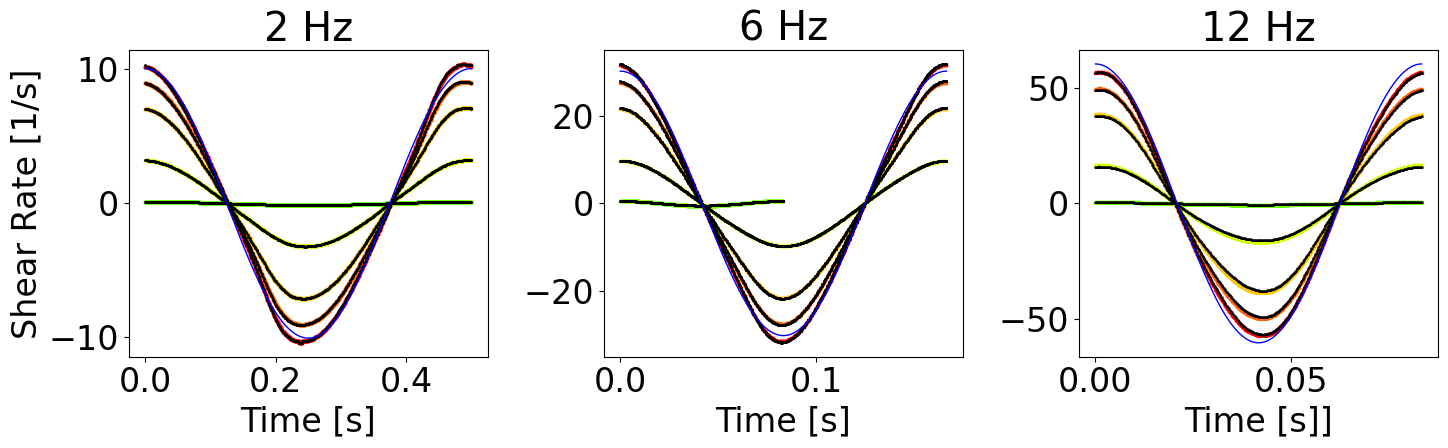

In [170]:
# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].set_xlabel('Time [s]')
axs[1].set_xlabel('Time [s]')
axs[2].set_xlabel('Time [s]]')
axs[0].set_ylabel('Shear Rate [1/s]')

axs[0].set_title('2 Hz')
axs[1].set_title('6 Hz')
axs[2].set_title('12 Hz')

print(ndata_cycle)


for i in range(0,5):

    x1 = data_exp[i][0][-ndata_cycle:]
    y1 = data_exp[i][3][-ndata_cycle:]

    x2 = data_exp[i+10][0][-ndata_cycle:]
    y2 = data_exp[i+10][3][-ndata_cycle:]

    x3 = data_exp[i+20][0][-ndata_cycle:]
    y3 = data_exp[i+20][3][-ndata_cycle:]

    # Plot data in the first subplot
    axs[0].plot(x1, y1, marker='o', color=color_palette[i], label='Data 1', markersize=2, linewidth =0)

    # Plot data in the second subplot
    axs[1].plot(x2, y2, marker='s', color=color_palette[i], label='Data 2', markersize=2, linewidth =0)

    # Plot data in the third subplot
    axs[2].plot(x3, y3, marker='^', color=color_palette[i], label='Data 3', markersize=2, linewidth =0)


for i in range(5,10):

    x1 = data_exp[i][0][-ndata_cycle:]
    y1 = data_exp[i][3][-ndata_cycle:]

    x2 = data_exp[i+10][0][-ndata_cycle:]
    y2 = data_exp[i+10][3][-ndata_cycle:]

    x3 = data_exp[i+20][0][-ndata_cycle:]
    y3 = data_exp[i+20][3][-ndata_cycle:]

    # Plot data in the first subplot
    axs[0].plot(x1, y1, marker='o', color='black', label='Data 1', markersize=1, linewidth =0)

    # Plot data in the second subplot
    axs[1].plot(x2, y2, marker='s', color='black', label='Data 2', markersize=1, linewidth =0)

    # Plot data in the third subplot
    axs[2].plot(x3, y3, marker='^', color='black', label='Data 3', markersize=1, linewidth =0)

# Adjust layout for better spacing
plt.tight_layout()


freq = 2
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[0].plot(t, shrates, marker='o', color='blue', markersize=0, linewidth =1)

freq = 6
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[1].plot(t, shrates, marker='o', color='blue', markersize=0, linewidth =1)

freq = 12
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[2].plot(t, shrates, marker='o', color='blue', markersize=0, linewidth =1)


# Display the plots
plt.show()

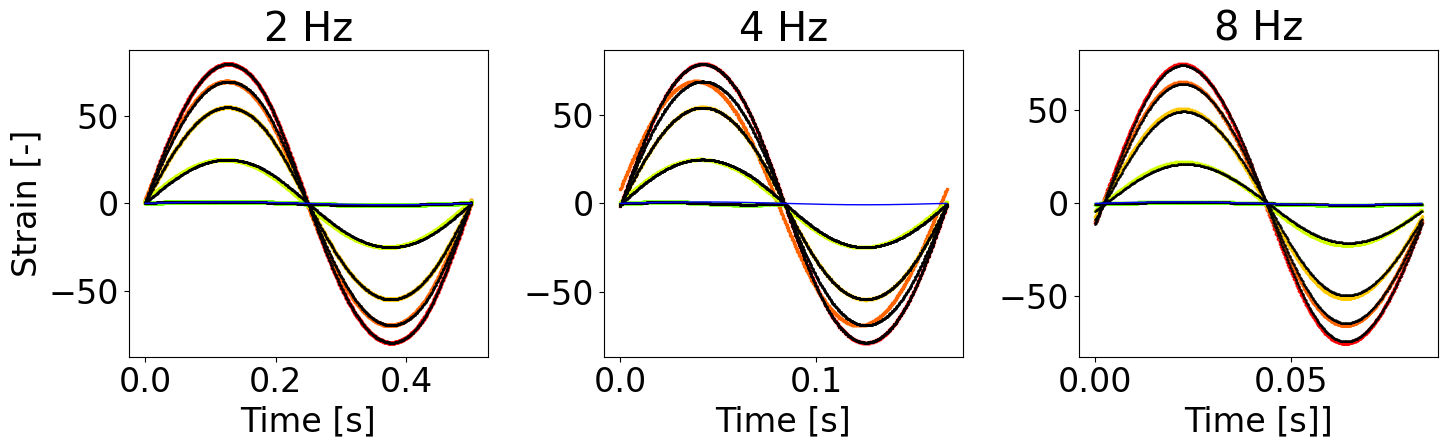

In [172]:
# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].set_xlabel('Time [s]')
axs[1].set_xlabel('Time [s]')
axs[2].set_xlabel('Time [s]]')
axs[0].set_ylabel('Strain [-]')

axs[0].set_title('2 Hz')
axs[1].set_title('4 Hz')
axs[2].set_title('8 Hz')


for i in range(0,5):

    x1 = data_exp[i][0][-ndata_cycle:]
    y1 = data_exp[i][2][-ndata_cycle:]

    x2 = data_exp[i+10][0][-ndata_cycle:]
    y2 = data_exp[i+10][2][-ndata_cycle:]

    x3 = data_exp[i+20][0][-ndata_cycle:]
    y3 = data_exp[i+20][2][-ndata_cycle:]

    # Plot data in the first subplot
    axs[0].plot(x1, y1, marker='o', color=color_palette[i], label='Data 1', markersize=2, linewidth =0)

    # Plot data in the second subplot
    axs[1].plot(x2, y2, marker='s', color=color_palette[i], label='Data 2', markersize=2, linewidth =0)

    # Plot data in the third subplot
    axs[2].plot(x3, y3, marker='^', color=color_palette[i], label='Data 3', markersize=2, linewidth =0)



for i in range(5,10):

    x1 = data_exp[i][0][-ndata_cycle:]
    y1 = data_exp[i][2][-ndata_cycle:]

    x2 = data_exp[i+10][0][-ndata_cycle:]
    y2 = data_exp[i+10][2][-ndata_cycle:]

    x3 = data_exp[i+20][0][-ndata_cycle:]
    y3 = data_exp[i+20][2][-ndata_cycle:]

    # Plot data in the first subplot
    axs[0].plot(x1, y1, marker='o', color='black', label='Data 1', markersize=1, linewidth =0)

    # Plot data in the second subplot
    axs[1].plot(x2, y2, marker='s', color='black', label='Data 2', markersize=1, linewidth =0)

    # Plot data in the third subplot
    axs[2].plot(x3, y3, marker='^', color='black', label='Data 3', markersize=1, linewidth =0)

# Adjust layout for better spacing
plt.tight_layout()


freq = 2
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[0].plot(t, strains, marker='o', color='blue', markersize=0, linewidth =1)

freq = 6
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[1].plot(t, strains, marker='o', color='blue', markersize=0, linewidth =1)

freq = 12
ampl = 80
t = np.linspace(0,1/freq,ndata_cycle)
strains = []
shrates =[]
for elem in t:
    shrate = ampl/100 * freq*2*math.pi * np.cos(freq*elem*2*math.pi)
    
    strain = ampl/100 * np.sin(freq*elem*2*math.pi)
    strains.append(strain)
    shrates.append(shrate)
axs[2].plot(t, strains, marker='o', color='blue', markersize=0, linewidth =1)


# Display the plots
plt.show()

Average the replicates

In [177]:
freq2_rep1 = []
freq4_rep1 = []
freq8_rep1 = []
freq2_rep2 = []
freq4_rep2 = []
freq8_rep2 = []

for i in range(0,len(data_exp)):
    if i < 5:
        freq2_rep1.append(data_exp[i])
    elif i < 10:
        freq2_rep2.append(data_exp[i])
    elif i < 15:
        freq4_rep1.append(data_exp[i])
    elif i < 20:
        freq4_rep2.append(data_exp[i])
    elif i < 25:
        freq8_rep1.append(data_exp[i])
    elif i < 30:
        freq8_rep2.append(data_exp[i])


mean_freq2 = []
mean_freq4 = []
mean_freq8 = []
std_freq2 = []
std_freq4 = []
std_freq8 = []
for i in range(0,len(freq2_rep1)):

    m2=[]
    s2=[]
    m4=[]
    s4=[]
    m8=[]
    s8=[]
    for k in range(0,len(freq2_rep1[i][1])):

        mean2 = np.average([freq2_rep1[i][1][k],freq2_rep2[i][1][k]])
        std2 = np.std([freq2_rep1[i][1][k],freq2_rep2[i][1][k]])
        mean4 = np.average([freq4_rep1[i][1][k],freq4_rep2[i][1][k]])
        std4 = np.std([freq4_rep1[i][1][k],freq4_rep2[i][1][k]])
        mean8 = np.average([freq8_rep1[i][1][k],freq8_rep2[i][1][k]])
        std8 = np.std([freq8_rep1[i][1][k],freq8_rep2[i][1][k]])

        m2.append(mean2)
        s2.append(std2)
        m4.append(mean4)
        s4.append(std4)
        m8.append(mean8)
        s8.append(std8)

    mean_freq2.append(m2)
    mean_freq4.append(m4)
    mean_freq8.append(m8)
    std_freq2.append(s2)
    std_freq4.append(s4)
    std_freq8.append(s8)

# #treat nans
# for i in range(0,5):
#     for k in range(0,len(mean_freq8[i])): 
#         if np.isnan(data_exp[i+28][0][k]): 
#             data_exp[i+28][0][k] = (data_exp[i+28][0][k-1] + data_exp[i+28][0][k+1])/2
#         if np.isnan(mean_freq8[i][k]): 
#             mean_freq8[i][k] = (mean_freq8[i][k-1] + mean_freq8[i][k+1])/2
#         if np.isnan(data_exp[i+28][2][k]): 
#             data_exp[i+28][2][k] = (data_exp[i+28][2][k-1] + data_exp[i+28][2][k+1])/2
#         if np.isnan(data_exp[i+28][3][k]): 
#             data_exp[i+28][3][k] = (data_exp[i+28][3][k-1] + data_exp[i+28][3][k+1])/2




data_exp_avg = []
for i in range(0,5):
    elem = []
    for k in range(0,4): #for each axis
       if k == 0: elem.append(data_exp[i][0])
       if k == 1: elem.append(mean_freq2[i])
       if k == 2: elem.append(data_exp[i][2])
       if k == 3: elem.append(data_exp[i][3])
    data_exp_avg.append(elem)
for i in range(0,5):
    elem = []
    for k in range(0,4):
       if k == 0: elem.append(data_exp[i+10][0])
       if k == 1: elem.append(mean_freq4[i])
       if k == 2: elem.append(data_exp[i+10][2])
       if k == 3: elem.append(data_exp[i+10][3])
    data_exp_avg.append(elem)
for i in range(0,5):
    elem = []
    for k in range(0,4):
       if k == 0: elem.append(data_exp[i+20][0])
       if k == 1: elem.append(mean_freq8[i])
       if k == 2: elem.append(data_exp[i+20][2])
       if k == 3: elem.append(data_exp[i+20][3])
    data_exp_avg.append(elem)


In [178]:
for i in range(0,5):
    has_nan = any(math.isnan(x) for x in data_exp[i+20][1])
    print(has_nan) 

False
False
False
False
False


Plot with errorbars

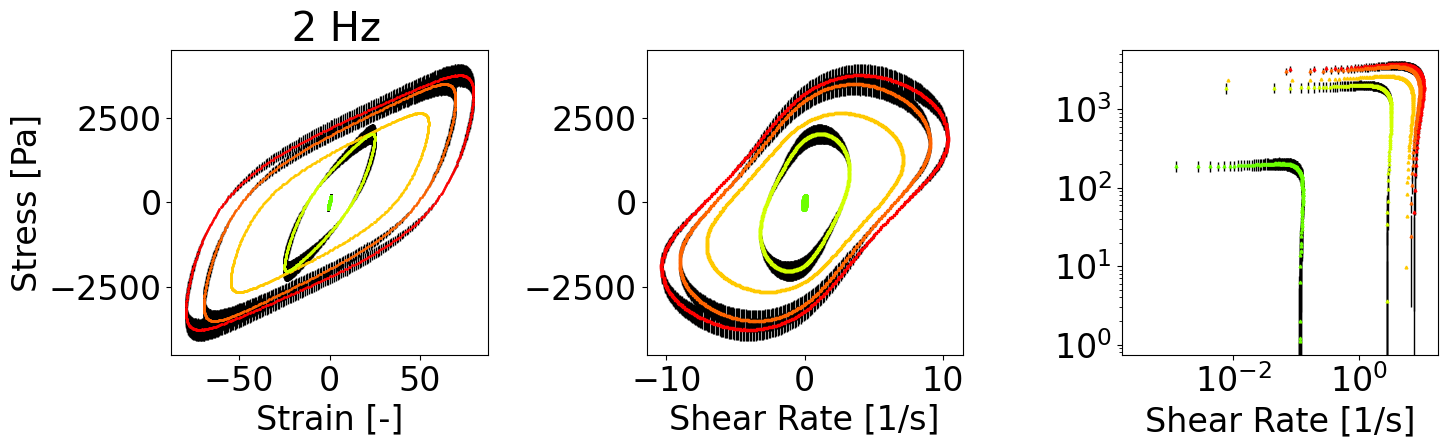

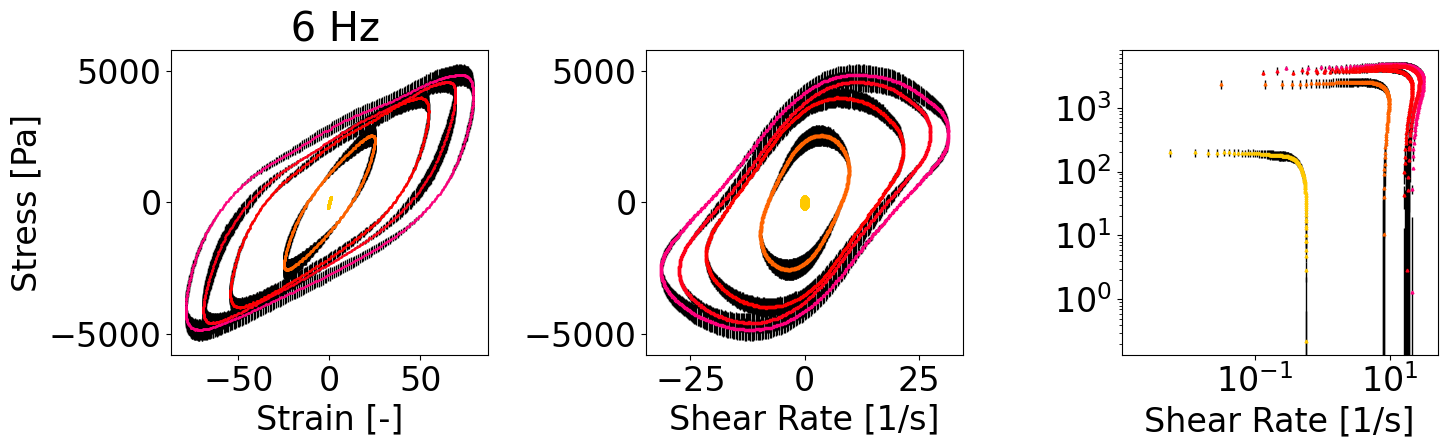

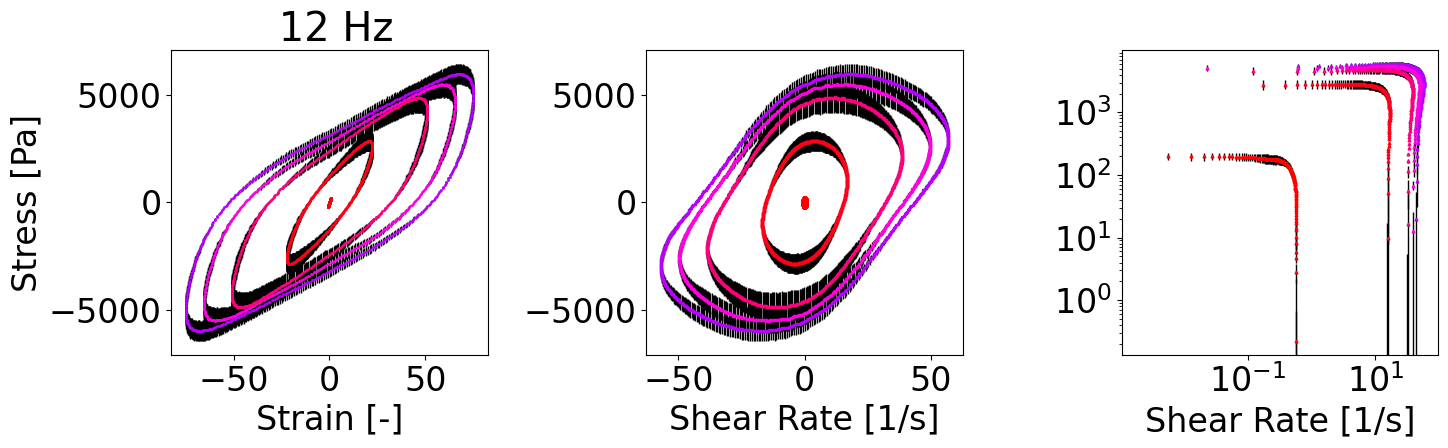

In [180]:
# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15,5))
axs[2].set_xscale('log')
axs[2].set_yscale('log')



axs[0].set_xlabel('Strain [-]')
axs[1].set_xlabel('Shear Rate [1/s]')
axs[2].set_xlabel('Shear Rate [1/s]')
axs[0].set_ylabel('Stress [Pa]')
axs[0].set_title(' 2 Hz')

std_all = []
for stdval in std_freq2: std_all.append(stdval)
for stdval in std_freq4: std_all.append(stdval)
for stdval in std_freq8: std_all.append(stdval)

for i in range(0,5):

    err = std_all[i][-ndata_cycle:]
    lim1 = 0
    lim2 = ndata_cycle

    x1 = data_exp_avg[i][2][-ndata_cycle:]
    y1 = data_exp_avg[i][1][-ndata_cycle:]

    x2 = data_exp_avg[i][3][-ndata_cycle:]
    y2 = data_exp_avg[i][1][-ndata_cycle:]

    x3 = data_exp_avg[i][3][-ndata_cycle:][lim1:lim2]
    y3 = data_exp_avg[i][1][-ndata_cycle:][lim1:lim2]



    # Plot data in the first subplot
    axs[0].errorbar(x1, y1, yerr=err, marker='o', color=color_palette[i], label='Data 1', markersize=1, linewidth =0, ecolor = 'black', elinewidth=1)

    # Plot data in the second subplot
    axs[1].errorbar(x2, y2, yerr=err, marker='s', color=color_palette[i], label='Data 2', markersize=2, linewidth =0 , ecolor = 'black', elinewidth=1)

    # Plot data in the third subplot
    axs[2].errorbar(x3, y3, yerr=err[lim1:lim2], marker='^', color=color_palette[i], label='Data 3', markersize=2, linewidth =0, ecolor = 'black', elinewidth=1)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[0].set_xlabel('Strain [-]')
axs[1].set_xlabel('Shear Rate [1/s]')
axs[2].set_xlabel('Shear Rate [1/s]')
axs[0].set_ylabel('Stress [Pa]')
axs[0].set_title(' 6 Hz')


for i in range(5,10):

    err = std_all[i][-ndata_cycle:]
    lim1 = 0
    lim2 = ndata_cycle

    x1 = data_exp_avg[i][2][-ndata_cycle:]
    y1 = data_exp_avg[i][1][-ndata_cycle:]

    x2 = data_exp_avg[i][3][-ndata_cycle:]
    y2 = data_exp_avg[i][1][-ndata_cycle:]

    x3 = data_exp_avg[i][3][-ndata_cycle:][lim1:lim2]
    y3 = data_exp_avg[i][1][-ndata_cycle:][lim1:lim2]



    # Plot data in the first subplot
    axs[0].errorbar(x1, y1, yerr=err, marker='o', color=color_palette[i-7], label='Data 1', markersize=1, linewidth =0, ecolor = 'black', elinewidth=1)

    # Plot data in the second subplot
    axs[1].errorbar(x2, y2, yerr=err, marker='s', color=color_palette[i-7], label='Data 2', markersize=2, linewidth =0 , ecolor = 'black', elinewidth=1)

    # Plot data in the third subplot
    axs[2].errorbar(x3, y3, yerr=err[lim1:lim2], marker='^', color=color_palette[i-7], label='Data 3', markersize=2, linewidth =0, ecolor = 'black', elinewidth=1)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()


# Create a figure and an array of axes with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[0].set_xlabel('Strain [-]')
axs[1].set_xlabel('Shear Rate [1/s]')
axs[2].set_xlabel('Shear Rate [1/s]')
axs[0].set_ylabel('Stress [Pa]')
axs[0].set_title(' 12 Hz')


for i in range(10,15):

    err = std_all[i][-ndata_cycle:]
    lim1 = 0
    lim2 = ndata_cycle

    x1 = data_exp_avg[i][2][-ndata_cycle:]
    y1 = data_exp_avg[i][1][-ndata_cycle:]

    x2 = data_exp_avg[i][3][-ndata_cycle:]
    y2 = data_exp_avg[i][1][-ndata_cycle:]

    x3 = data_exp_avg[i][3][-ndata_cycle:][lim1:lim2]
    y3 = data_exp_avg[i][1][-ndata_cycle:][lim1:lim2]



    # Plot data in the first subplot
    axs[0].errorbar(x1, y1, yerr=err, marker='o', color=color_palette[i-14], label='Data 1', markersize=1, linewidth =0, ecolor = 'black', elinewidth=1)

    # Plot data in the second subplot
    axs[1].errorbar(x2, y2, yerr=err, marker='s', color=color_palette[i-14], label='Data 2', markersize=2, linewidth =0 , ecolor = 'black', elinewidth=1)

    # Plot data in the third subplot
    axs[2].errorbar(x3, y3, yerr=err[lim1:lim2], marker='^', color=color_palette[i-14], label='Data 3', markersize=2, linewidth =0, ecolor = 'black', elinewidth=1)

# Adjust layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()

## Stress Growth

In [16]:
#   Inputs
n_header= 105 #header rows just from the begining to the first data
n_rows=99 #number of data points in the measurement
rows_btw_data = 68 #number20 of rows between two measurements
header_list=[ 'Meas. Pts.','Time', 'Strain', 'Shear Rate', 'Shear Stress',\
            'Torque', 'Normal Force', 'Viscosity', 'Status']
what_to_collect_time_dep= ['Time', 'Strain', 'Shear Stress'  ]
what_to_collect_single_val = []
sheet_name = 'STEADY'

sample_list = ['01-growth-P60-0.60-0.063',\
               '02-growth-P60-0.60-0.100',\
               '03-growth-P60-0.60-0.170',\
               '04-growth-P60-0.60-0.280',\
               '05-growth-P60-0.60-0.450',\
               '06-growth-P60-0.60-0.730',\
               '07-growth-P60-0.60-1.20',\
               '08-growth-P60-0.60-1.96',\
               '09-growth-P60-0.60-3.21',\
               '10-growth-P60-0.60-5.25',\
               '11-growth-P60-0.60-8.58',\
               '12-growth-P60-0.60-14.1',\
               '13-growth-P60-0.60-23.0',\
               '14-growth-P60-0.60-37.0',\
               '15-growth-P60-0.60-61.0',\
               '16-growth-P60-0.60-0.063',\
               '17-growth-P60-0.60-0.100',\
               '18-growth-P60-0.60-0.170',\
               '19-growth-P60-0.60-0.280',\
               '20-growth-P60-0.60-0.450',\
               '21-growth-P60-0.60-0.730',\
               '22-growth-P60-0.60-1.20',\
               '23-growth-P60-0.60-1.96',\
               '24-growth-P60-0.60-3.21',\
               '25-growth-P60-0.60-5.25',\
               '26-growth-P60-0.60-8.58',\
               '27-growth-P60-0.60-14.1',\
               '28-growth-P60-0.60-23.0',\
               '29-growth-P60-0.60-37.0',\
               '30-growth-P60-0.60-61.0',\
               ]  
 

#   Function
data_exp_stgrw= read_data1(n_header, n_rows, header_list, what_to_collect_time_dep,\
               path_read, sheet_name, sample_list, rows_btw_data)

Get the average of replicates

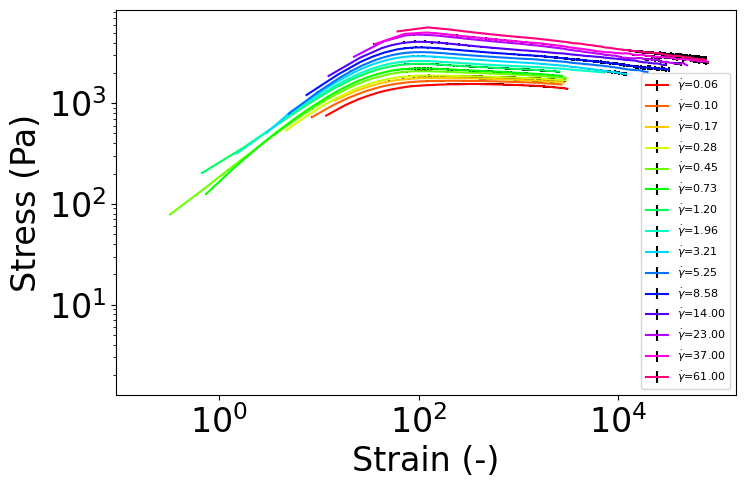

In [17]:
first_rep = []
second_rep = []
i=0
for elem in data_exp_stgrw:
    # elem[1]: strain
    # elem[2]: stress

    if i < 15: # there are 15 shear rates
        first_rep.append(elem[2])
    if i >= 15:
        second_rep.append(elem[2])
    i+=1

avg = []
std_strgrw = []
for n in range(0,len(first_rep)):
    avg_elem = []
    std_elem = []
    for m in range(0,len(first_rep[n])):
        array = [first_rep[n][m], second_rep[n][m]]
        avg_val = np.average(array)
        std_val = np.std(array)
        avg_elem.append(avg_val)
        std_elem.append(std_val)
    
    avg.append(avg_elem)
    std_strgrw.append(std_elem)

data_exp_stgrw_avg = []

for i in range(0,len(str_grw_shear_rates)):
    elem = []
    for k in range(0,3):
        if k == 0: elem.append(data_exp_stgrw[i][0])
        if k == 1: elem.append(data_exp_stgrw[i][1])
        if k == 2: elem.append(avg[i])
    data_exp_stgrw_avg.append(elem)


fig, axs = plt.subplots(figsize=(8, 5))
axs.set_xscale('log')
axs.set_yscale('log')
axs.set_xlabel('Strain (-)')
axs.set_ylabel('Stress (Pa)')

i=0
for elem in range(0,len(data_exp_stgrw_avg)):
    axs.errorbar(data_exp_stgrw_avg[i][1],data_exp_stgrw_avg[i][2], yerr=std_strgrw[i],\
                  label='$\dot{{\gamma}}$={:1.2f}'.format(str_grw_shear_rates[i]), marker='o', markersize = 0,\
                  color=color_palette[i], ecolor='black')

    i+=1
axs.legend(fontsize=8)



To do: \
Include errorbars in new plots

# Write Data

In [181]:
varname_list = []
for var_name in dir():
    # Skip private/internal variables
    if not var_name.startswith('_'):
        var_value = eval(var_name)
        
        # Check if the variable is a NumPy array (or any other array-like type)
        if isinstance(var_value, (np.ndarray, list)):
            varname_list.append(var_name)

varname_list_sorted = sorted(varname_list)

for k in range(0, len(varname_list_sorted)):
    text = f"'{varname_list_sorted[k]}',"
    print(text)



'G1rep1',
'G1rep2',
'G2rep1',
'G2rep2',
'In',
'avg',
'axs',
'color_palette',
'data_exp',
'data_exp_avg',
'data_exp_frswp',
'data_exp_frswp_avg',
'data_exp_frswp_raw',
'data_exp_frswp_waveform',
'data_exp_frswp_waveform_avg',
'data_exp_strswp',
'data_exp_strswp_avg',
'data_single_exp',
'elem',
'elem1',
'elem2',
'elem3',
'elem4',
'err',
'filtered',
'filtered_array',
'freq2_rep1',
'freq2_rep2',
'freq4_rep1',
'freq4_rep2',
'freq8_rep1',
'freq8_rep2',
'freqvals_frfit',
'header_list',
'input_array',
'm2',
'm4',
'm8',
'mean_freq2',
'mean_freq4',
'mean_freq8',
'non',
'rep1',
'rep2',
's2',
's4',
's8',
'sample_list',
'sheet_name',
'shrates',
'std_all',
'std_freq2',
'std_freq4',
'std_freq8',
'std_freq_swp',
'std_freqwaveform',
'std_str_swp',
'stdval',
'str_grw_shear_rates',
'strains',
't',
'varname_list',
'what_to_collect_single',
'what_to_collect_single_val',
'what_to_collect_time',
'what_to_collect_time_dep',
'x',
'x1',
'x2',
'x3',
'y1',
'y2',
'y3',


In [182]:
#get current time
current_time = datetime.datetime.now()
formatted_time = current_time.strftime('%Y_%m_%d_%H_%M')

export_items= [
'data_exp_avg',
'data_exp_frswp_avg',
'data_exp_frswp_waveform_avg',
'data_exp_strswp_avg',
'std_all',
'std_freq_swp',
'std_freqwaveform',
'std_str_swp',
]

# Open a new file to store variables
with open(f'data_reading/arrays_{formatted_time}_humanreadable.py', 'w') as f:
    for var_name in dir():
        # Skip private/internal variables
        if not var_name.startswith('_'):
            var_value = eval(var_name)
            
            # Check if the variable is a NumPy array (or any other array-like type)
            if isinstance(var_value, (np.ndarray, list)):

                if var_name in export_items:
                    # Write variable assignment to the file
                    text1 = f'{var_name} = {repr(var_value)}'
                    f.write(textwrap.fill(text1, width=80))
                    f.write('\n')

np.savez(f'data_reading/arrays_{formatted_time}.npz', **{name: eval(name) for name in export_items})
